In [30]:
import pandas as pd

df = pd.read_csv('data/book_of_mormon.csv')
print(df.shape)
print(df.head())

(6585, 7)
   Book_Order     Book  Chapter  Verse Author  Word_Count  \
0           1  1 Nephi        1      1  Nephi          68   
1           1  1 Nephi        1      2  Nephi          25   
2           1  1 Nephi        1      3  Nephi          27   
3           1  1 Nephi        1      4  Nephi          56   
4           1  1 Nephi        1      5  Nephi          28   

                                                Text  
0  I, Nephi, having been born of goodly parents, ...  
1  Yea, I make a record in the language of my fat...  
2  And I know that the record which I make is tru...  
3  For it came to pass in the commencement of the...  
4  Wherefore it came to pass that my father, Lehi...  


In [31]:
# How many verses per author?
print("=== Verses per Author ===")
print(df['Author'].value_counts())

print("\n=== Verses per Book ===")
print(df['Book'].value_counts().sort_index())

print("\n=== Average Word Count per Author ===")
print(df.groupby('Author')['Word_Count'].mean().round(2).sort_values(ascending=False))

print("\n=== Any missing values? ===")
print(df.isnull().sum())

=== Verses per Author ===
Author
Mormon     4318
Nephi      1397
Moroni      595
Jacob       203
Various      30
Enos         27
Jarom        15
Name: count, dtype: int64

=== Verses per Book ===
Book
1 Nephi     618
2 Nephi     779
3 Nephi     785
4 Nephi      49
Alma       1975
Enos         27
Ether       433
Helaman     497
Jacob       203
Jarom        15
Mormon      227
Moroni      162
Mosiah      785
Omni         30
Name: count, dtype: int64

=== Average Word Count per Author ===
Author
Various    77.53
Jarom      48.73
Jacob      44.96
Enos       42.81
Mormon     40.85
Nephi      39.03
Moroni     38.10
Name: Word_Count, dtype: float64

=== Any missing values? ===
Book_Order    0
Book          0
Chapter       0
Verse         0
Author        0
Word_Count    0
Text          0
dtype: int64


In [32]:
import nltk
import string
from collections import Counter

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english')) | {'unto', 'came', 'pass', 'upon', 'also', 'shall', 'said', 'come', 'forth', 'yea', 'thus', 'even', 'thereof', 'whereby', 'therefore', 'behold', 'wherefore', 'hath', 'thou', 'many', 'lord', 'god', 'people', 'land', 'ye', 'things', 'great'}

def get_word_freq(author, top_n=20):
    text = ' '.join(df[df['Author'] == author]['Text'].tolist())
    
    # Lowercase, remove punctuation, split
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    
    # Remove stopwords and short words
    words = [w for w in words if w not in stop_words and len(w) > 3]
    
    return Counter(words).most_common(top_n)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/drewgladwell/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
authors = df['Author'].unique()

for author in authors:
    print(f"\n=== Top 10 Words for {author} ===")
    for word, count in get_word_freq(author, top_n=10):
        print(f"  {word}: {count}")


=== Top 10 Words for Nephi ===
  father: 169
  words: 168
  israel: 134
  brethren: 123
  know: 120
  away: 114
  earth: 112
  nephi: 111
  children: 111
  according: 107

=== Top 10 Words for Jacob ===
  vineyard: 91
  fruit: 68
  branches: 49
  tree: 43
  good: 32
  servant: 30
  natural: 29
  away: 28
  brethren: 28
  time: 27

=== Top 10 Words for Enos ===
  faith: 10
  enos: 6
  according: 6
  lamanites: 6
  would: 6
  heard: 5
  father: 4
  soul: 4
  brethren: 4
  nephites: 4

=== Top 10 Words for Jarom ===
  write: 5
  according: 5
  exceedingly: 5
  face: 5
  plates: 4
  lamanites: 4
  kept: 3
  written: 3
  fathers: 3
  much: 3

=== Top 10 Words for Various ===
  words: 21
  mormon: 21
  plates: 16
  king: 16
  mosiah: 13
  benjamin: 13
  according: 12
  zarahemla: 11
  concerning: 10
  hands: 8

=== Top 10 Words for Mormon ===
  lamanites: 647
  among: 445
  would: 437
  king: 422
  words: 412
  might: 365
  brethren: 353
  according: 340
  nephites: 340
  began: 335

=== To

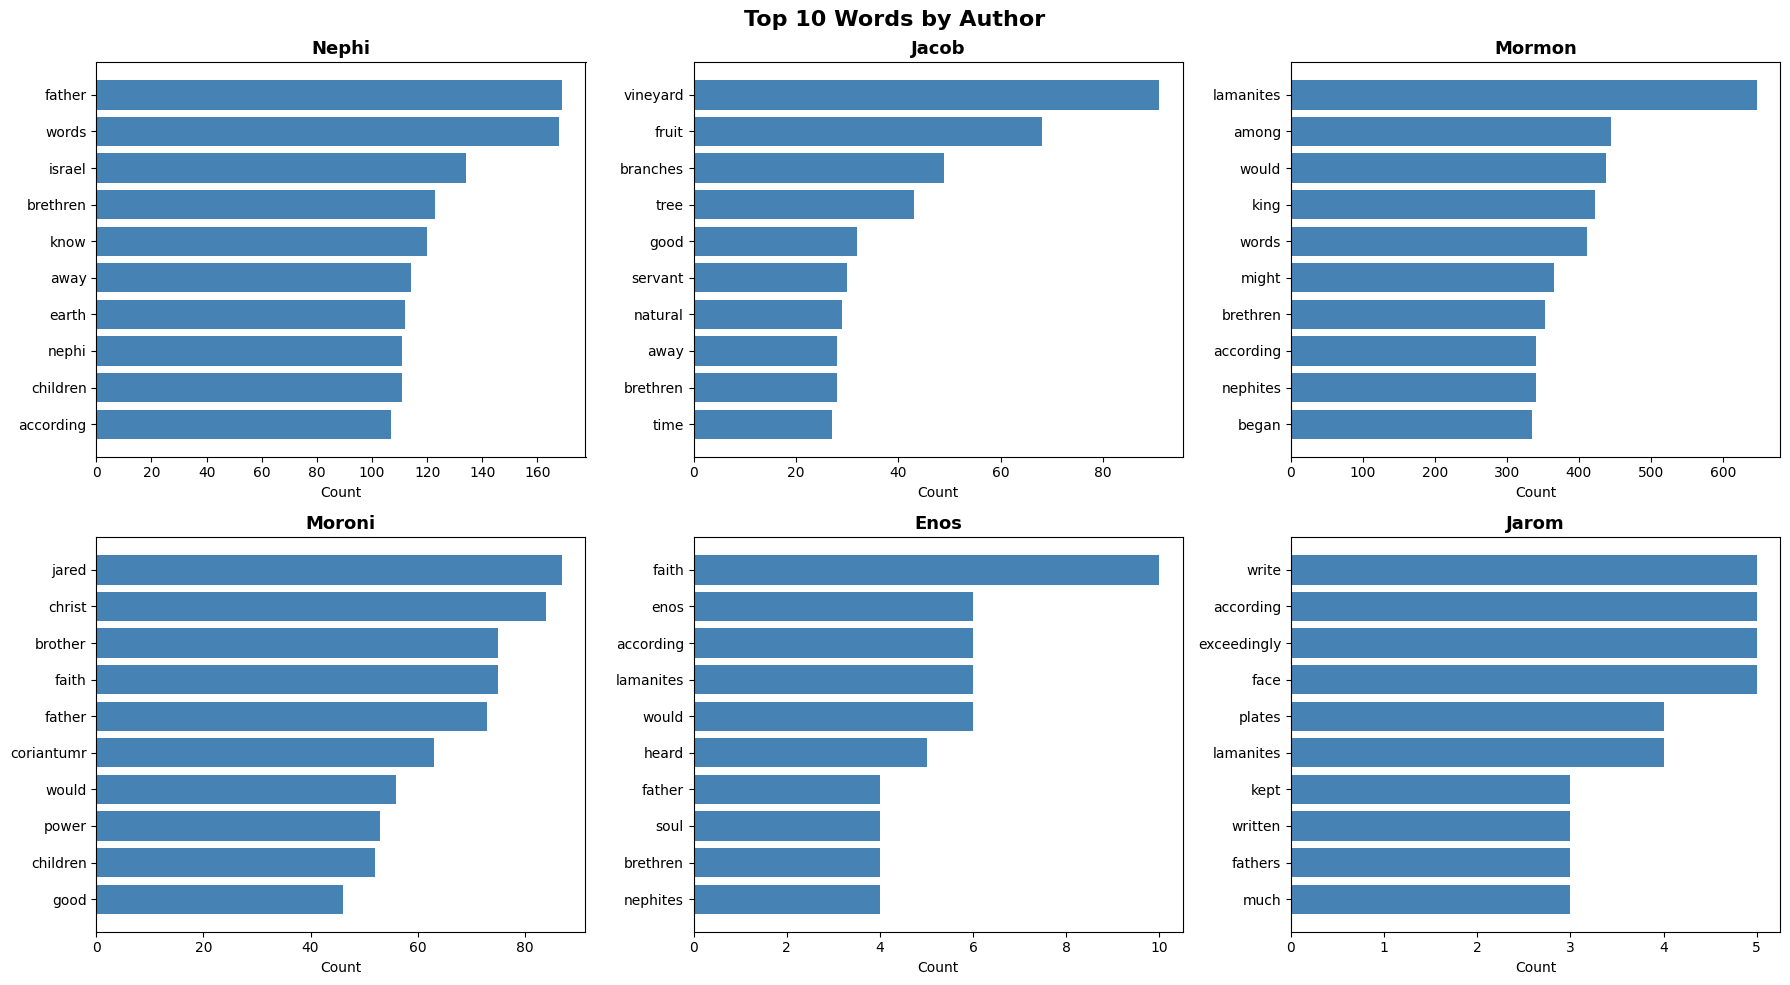

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 10 Words by Author', fontsize=16, fontweight='bold')

authors = ['Nephi', 'Jacob', 'Mormon', 'Moroni', 'Enos', 'Jarom']

for i, author in enumerate(authors):
    row, col = divmod(i, 3)
    words, counts = zip(*get_word_freq(author, top_n=10))
    
    axes[row, col].barh(words, counts, color='steelblue')
    axes[row, col].set_title(f'{author}', fontsize=13, fontweight='bold')
    axes[row, col].invert_yaxis()
    axes[row, col].set_xlabel('Count')

plt.tight_layout()
plt.savefig('outputs/word_frequency_by_author.png', dpi=150)
plt.show()

In [35]:
def vocab_richness(author):
    text = ' '.join(df[df['Author'] == author]['Text'].tolist())
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if len(w) > 3]
    
    total_words = len(words)
    unique_words = len(set(words))
    richness = unique_words / total_words
    
    return {
        'Author': author,
        'Total Words': total_words,
        'Unique Words': unique_words,
        'Richness Score': round(richness, 4)
    }

authors = ['Nephi', 'Jacob', 'Mormon', 'Moroni', 'Enos', 'Jarom', 'Various']
richness_df = pd.DataFrame([vocab_richness(a) for a in authors])
richness_df = richness_df.sort_values('Richness Score', ascending=False)
print(richness_df.to_string(index=False))

 Author  Total Words  Unique Words  Richness Score
  Jarom          387           214          0.5530
   Enos          617           297          0.4814
Various         1268           382          0.3013
  Jacob         5141           931          0.1811
 Moroni        12359          1600          0.1295
  Nephi        29346          2806          0.0956
 Mormon        97701          4561          0.0467


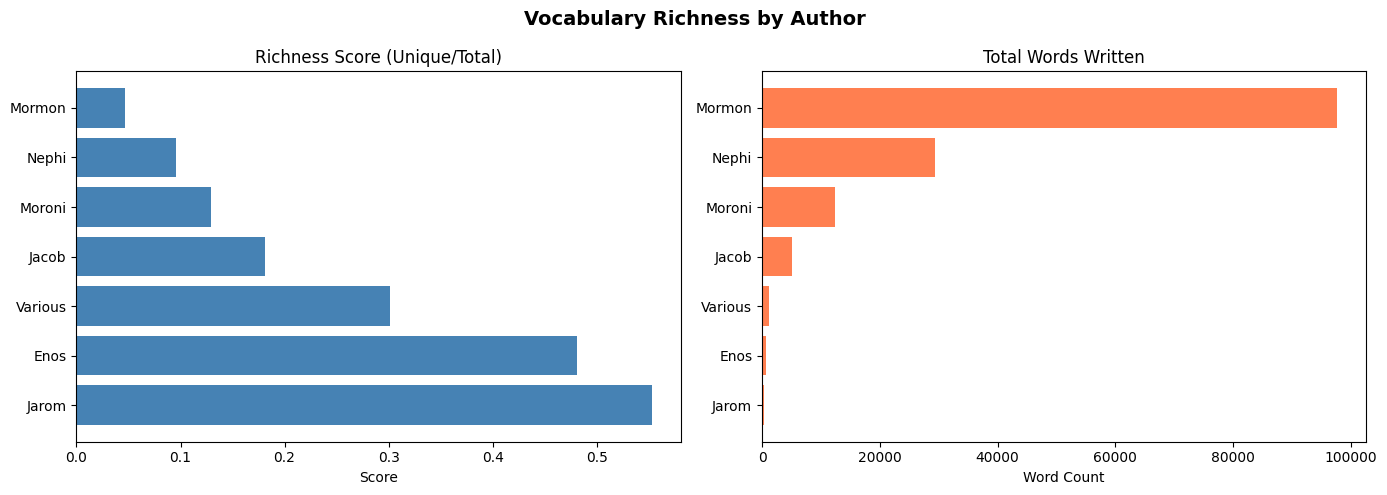

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vocabulary Richness by Author', fontsize=14, fontweight='bold')

# Left chart - Richness Score
axes[0].barh(richness_df['Author'], richness_df['Richness Score'], color='steelblue')
axes[0].set_title('Richness Score (Unique/Total)')
axes[0].set_xlabel('Score')

# Right chart - Total Words (for context)
axes[1].barh(richness_df['Author'], richness_df['Total Words'], color='coral')
axes[1].set_title('Total Words Written')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('outputs/vocab_richness.png', dpi=150)
plt.show()

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Combine all verses into one document per author
author_docs = df.groupby('Author')['Text'].apply(lambda x: ' '.join(x)).reset_index()

# Run TF-IDF
custom_stops = list(stop_words)  # this pulls in the stopwords we already built
vectorizer = TfidfVectorizer(stop_words=custom_stops, max_features=5000, ngram_range=(1,1))
tfidf_matrix = vectorizer.fit_transform(author_docs['Text'])
feature_names = vectorizer.get_feature_names_out()

# Print top 10 signature words per author
print("=== Top TF-IDF Signature Words Per Author ===\n")
for i, author in enumerate(author_docs['Author']):
    tfidf_scores = tfidf_matrix[i].toarray()[0]
    top_indices = np.argsort(tfidf_scores)[::-1][:10]
    top_words = [(feature_names[j], round(tfidf_scores[j], 4)) for j in top_indices]
    
    print(f"--- {author} ---")
    for word, score in top_words:
        print(f"  {word}: {score}")
    print()

=== Top TF-IDF Signature Words Per Author ===

--- Enos ---
  faith: 0.2944
  thy: 0.2676
  enos: 0.2639
  heard: 0.1672
  would: 0.1559
  according: 0.1559
  lamanites: 0.1559
  soul: 0.1178
  continually: 0.1039
  brethren: 0.1039

--- Jacob ---
  vineyard: 0.5059
  branches: 0.3152
  fruit: 0.2844
  tree: 0.2482
  may: 0.1657
  natural: 0.1595
  servant: 0.1432
  good: 0.138
  graft: 0.1085
  much: 0.0994

--- Jarom ---
  face: 0.217
  write: 0.1915
  according: 0.1915
  exceedingly: 0.1915
  plates: 0.1736
  lamanites: 0.1532
  jarom: 0.1517
  kept: 0.1302
  much: 0.1302
  faith: 0.1302

--- Mormon ---
  lamanites: 0.2036
  king: 0.1786
  city: 0.1567
  alma: 0.1541
  say: 0.1451
  year: 0.1434
  among: 0.1396
  would: 0.1374
  might: 0.1298
  words: 0.1293

--- Moroni ---
  jared: 0.3804
  coriantumr: 0.1955
  brother: 0.177
  christ: 0.1745
  faith: 0.1558
  begat: 0.1488
  may: 0.1412
  father: 0.1374
  son: 0.1371
  shiz: 0.1356

--- Nephi ---
  thy: 0.2209
  israel: 0.163
  fa

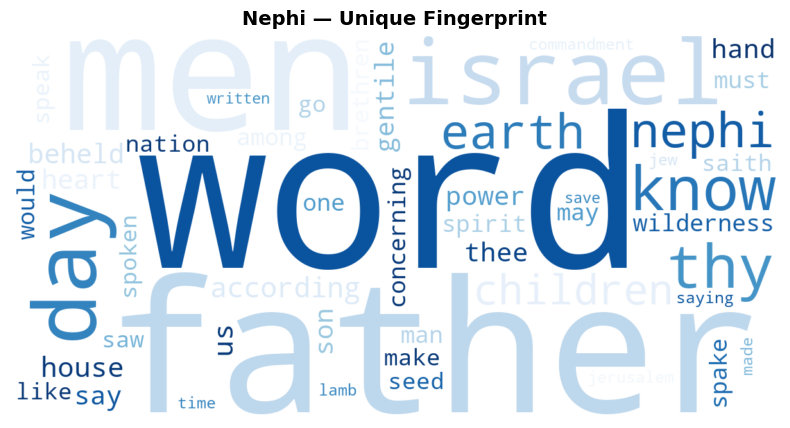

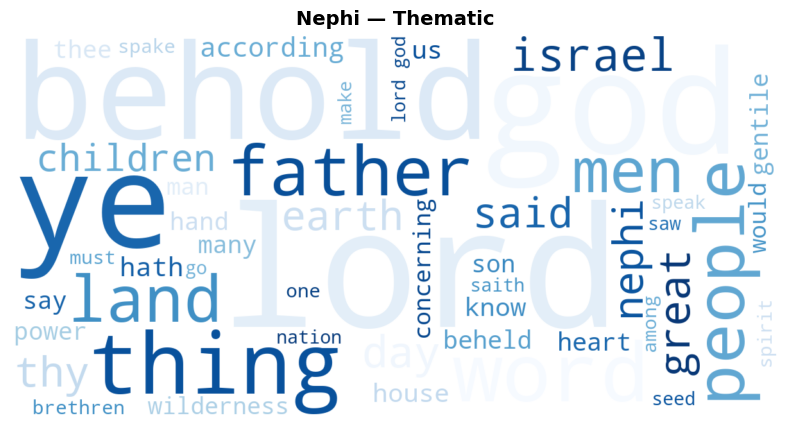

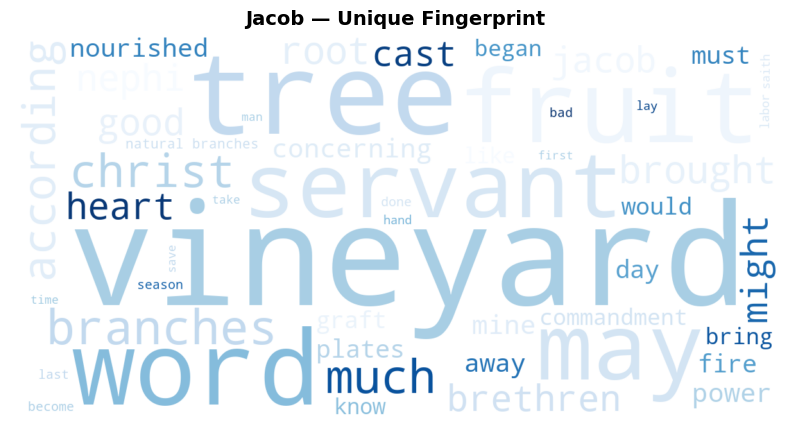

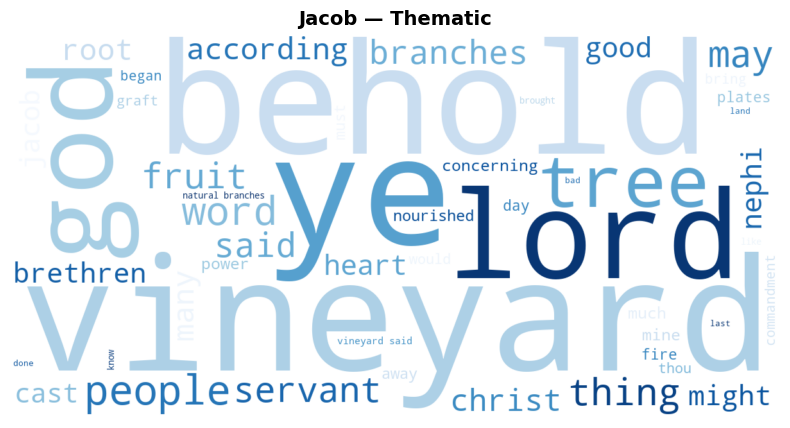

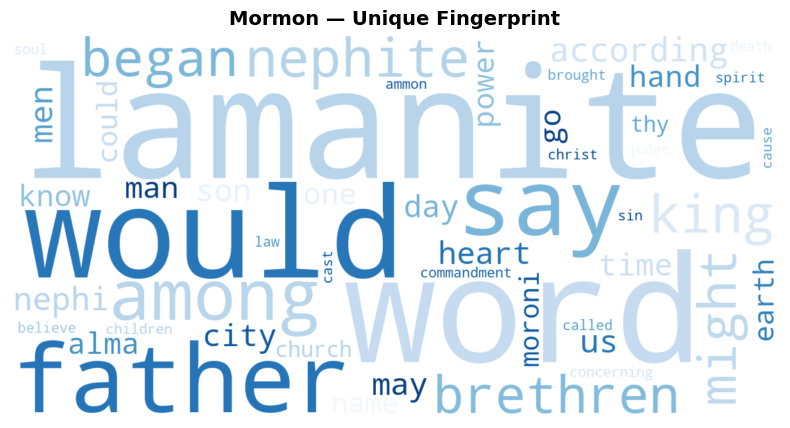

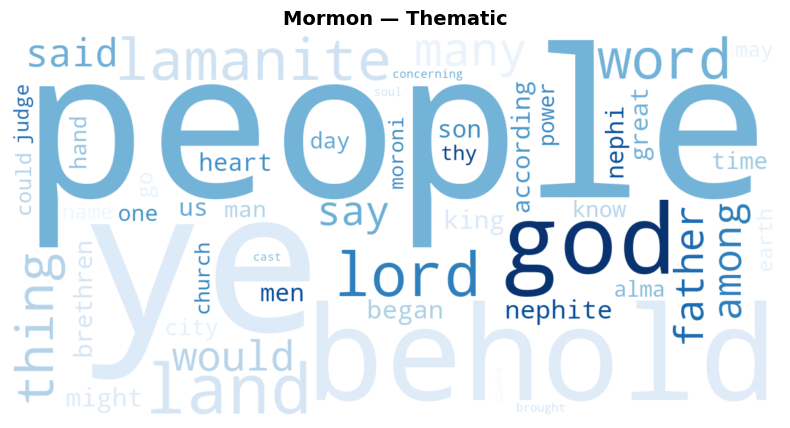

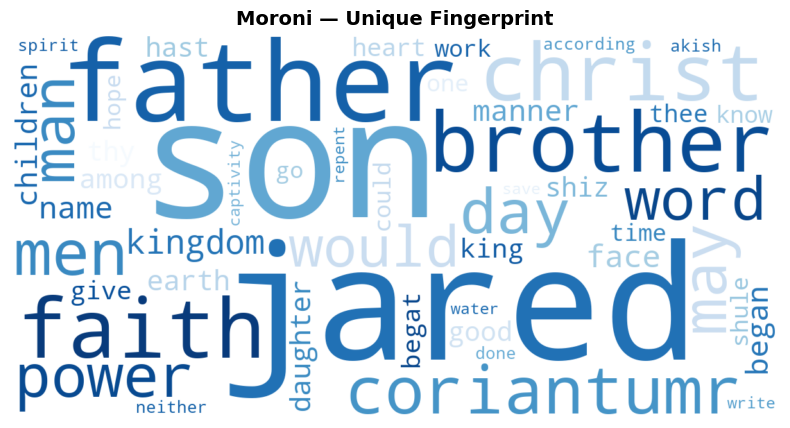

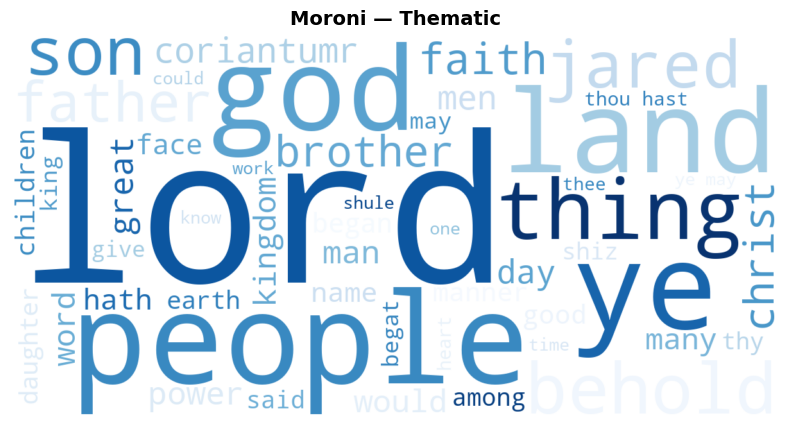

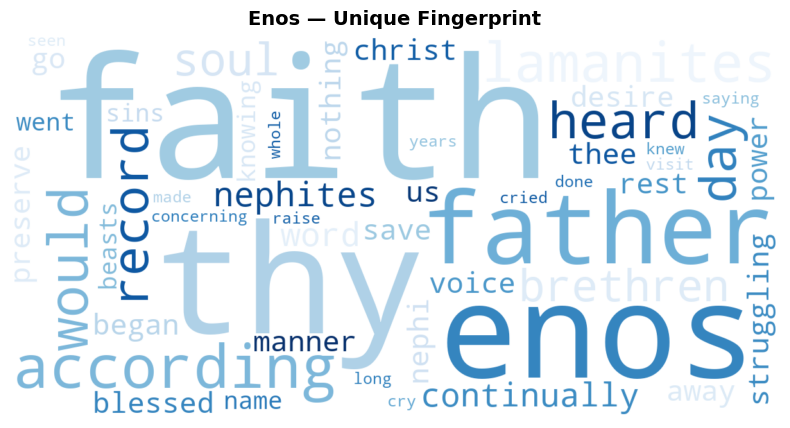

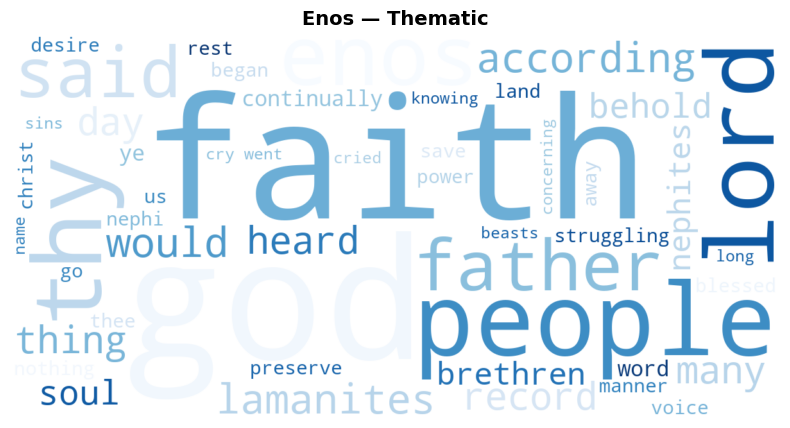

In [40]:
from wordcloud import WordCloud

# Minimal stopwords for thematic clouds
minimal_stops = set(stopwords.words('english')) | {'unto', 'came', 'pass', 'upon', 
                'also', 'shall', 'come', 'forth', 'yea', 'thus', 'even', 
                'thereof', 'whereby', 'therefore', 'wherefore'}

def make_wordcloud(author, custom_stopwords, title, filename):
    text = ' '.join(df[df['Author'] == author]['Text'].tolist())
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    
    wc = WordCloud(
    width=1200,      # wider than before
    height=600,      # taller than before
    background_color='white',
    stopwords=custom_stopwords,
    colormap='Blues',
    max_words=50,    # reduced from 80
    margin=10        # adds spacing between words
).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.savefig(f'outputs/{filename}', dpi=150)
    plt.show()

# Generate both versions for each main author
main_authors = ['Nephi', 'Jacob', 'Mormon', 'Moroni', 'Enos']

for author in main_authors:
    # Fingerprint version
    make_wordcloud(author, stop_words, 
                   f'{author} — Unique Fingerprint', 
                   f'wordcloud_{author.lower()}_fingerprint.png')
    
    # Thematic version
    make_wordcloud(author, minimal_stops, 
                   f'{author} — Thematic', 
                   f'wordcloud_{author.lower()}_thematic.png')

          Mean  Median  Std Dev
Author                         
Various  77.53    47.0   169.86
Jarom    48.73    47.0    17.27
Jacob    44.96    42.0    19.88
Enos     42.81    35.0    26.01
Mormon   40.85    38.0    17.97
Nephi    39.03    35.0    19.49
Moroni   38.10    36.0    18.04


/var/folders/gw/7h9qwsw96b3g127_0r96ptj80000gn/T/ipykernel_22261/2207653439.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=author_order)


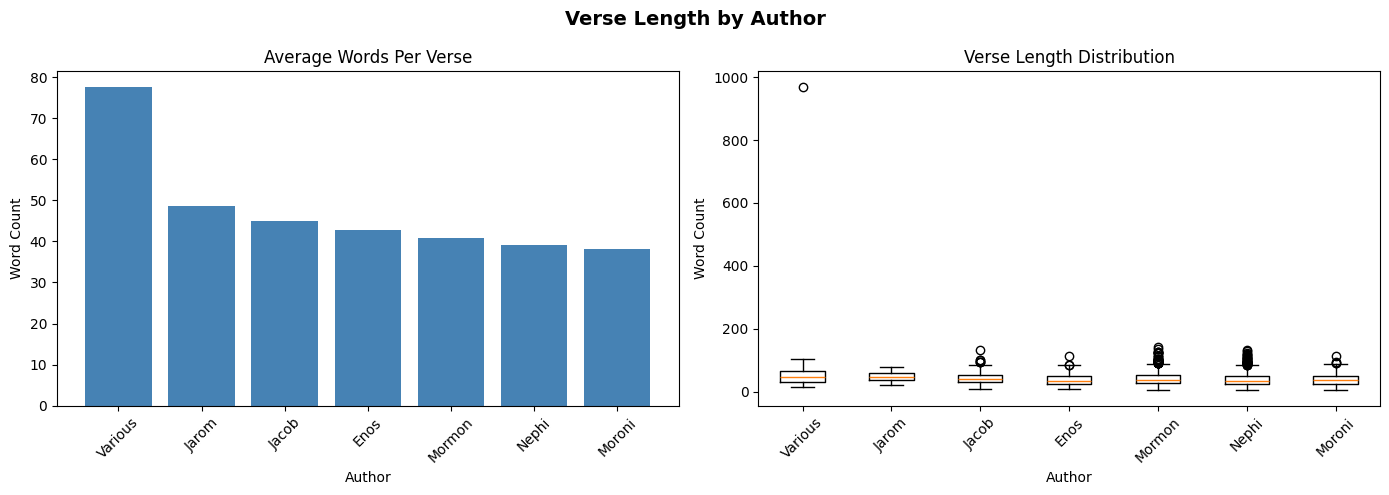

Book: Omni
Chapter: 1, Verse: 30
Word Count: 970
Text: And I, Amaleki, had a brother, who also went with them; and I have not since known concerning them. And I am about to lie down in my grave; and these plates are full. And I make an end of my speaking....


In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate stats per author
verse_stats = df.groupby('Author')['Word_Count'].agg(['mean', 'median', 'std']).round(2)
verse_stats = verse_stats.sort_values('mean', ascending=False)
verse_stats.columns = ['Mean', 'Median', 'Std Dev']
print(verse_stats)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Verse Length by Author', fontsize=14, fontweight='bold')

# Left - Mean verse length
axes[0].bar(verse_stats.index, verse_stats['Mean'], color='steelblue')
axes[0].set_title('Average Words Per Verse')
axes[0].set_xlabel('Author')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=45)

# Right - Distribution boxplot
author_order = verse_stats.index.tolist()
data = [df[df['Author'] == a]['Word_Count'].values for a in author_order]
axes[1].boxplot(data, labels=author_order)
axes[1].set_title('Verse Length Distribution')
axes[1].set_xlabel('Author')
axes[1].set_ylabel('Word Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/verse_length.png', dpi=150)
plt.show()

longest = df.loc[df['Word_Count'].idxmax()]
print(f"Book: {longest['Book']}")
print(f"Chapter: {longest['Chapter']}, Verse: {longest['Verse']}")
print(f"Word Count: {longest['Word_Count']}")
print(f"Text: {longest['Text'][:200]}...")

In [45]:
# 1. Verse level data (already have this - just save a clean version)
df.to_csv('outputs/tableau_verses.csv', index=False)

# 2. Vocabulary richness summary
richness_df.to_csv('outputs/tableau_vocab_richness.csv', index=False)

# 3. Verse length stats per author
verse_stats.reset_index().to_csv('outputs/tableau_verse_length.csv', index=False)

# 4. Word frequency per author (top 20 each)
freq_rows = []
for author in df['Author'].unique():
    for word, count in get_word_freq(author, top_n=20):
        freq_rows.append({'Author': author, 'Word': word, 'Count': count})

freq_df = pd.DataFrame(freq_rows)
freq_df.to_csv('outputs/tableau_word_freq.csv', index=False)

# 5. TF-IDF scores per author
tfidf_rows = []
for i, author in enumerate(author_docs['Author']):
    tfidf_scores = tfidf_matrix[i].toarray()[0]
    top_indices = np.argsort(tfidf_scores)[::-1][:20]
    for j in top_indices:
        tfidf_rows.append({
            'Author': author,
            'Word': feature_names[j],
            'TF_IDF_Score': round(tfidf_scores[j], 4)
        })

tfidf_df = pd.DataFrame(tfidf_rows)
tfidf_df.to_csv('outputs/tableau_tfidf.csv', index=False)

print("All files exported successfully!")
print("\nFiles created:")
print("  - tableau_verses.csv")
print("  - tableau_vocab_richness.csv")
print("  - tableau_verse_length.csv")
print("  - tableau_word_freq.csv")
print("  - tableau_tfidf.csv")

All files exported successfully!

Files created:
  - tableau_verses.csv
  - tableau_vocab_richness.csv
  - tableau_verse_length.csv
  - tableau_word_freq.csv
  - tableau_tfidf.csv
